# EDA - Comportamiento financiero ECF 2021

Este notebook analiza los **microdatos de la Encuesta de Competencias Financieras 2021** del Banco de España.

El objetivo es estudiar el **comportamiento financiero de la población** desde una perspectiva de negocio:

- Qué productos financieros tiene la población.
- Qué productos financieros adquiere realmente.
- Qué productos están consolidados.
- Qué productos tienen baja adquisición y pueden representar oportunidad.
- Qué acciones podría realizar el banco para impulsar su contratación.

El análisis se basa únicamente en 2021. No incluye proyecciones poblacionales ni análisis temporal, porque esa parte corresponde a otro equipo.


## 1. Carga de datos

El CSV de microdatos está separado por `;`, por eso se indica `sep=';'`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Ruta local del archivo descargado
ruta = "data/ecf_2021.csv"

# Carga de datos
try:
    datos = pd.read_csv(ruta, sep=';')
except FileNotFoundError:
    # Ruta alternativa por si el notebook se ejecuta en el mismo directorio del CSV
    datos = pd.read_csv('ecf_2021.csv', sep=';')

print(f"Dataset cargado: {datos.shape[0]} filas y {datos.shape[1]} columnas")
datos.info()


Dataset cargado: 7764 filas y 429 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7764 entries, 0 to 7763
Columns: 429 entries, a01 to ID
dtypes: float64(10), int64(419)
memory usage: 25.4 MB


## 2. Revisión inicial

In [2]:
display(datos.head())

print('Duplicados exactos:', datos.duplicated().sum())

revision = pd.DataFrame({
    'columna': datos.columns,
    'tipo': datos.dtypes.astype(str).values,
    'nulos': datos.isna().sum().values,
    'valores_unicos': [datos[c].nunique(dropna=True) for c in datos.columns]
})

display(revision.head(20))

,a01,a02,a0000,a0400,a04,a0800,a0100,a0320,a1030,a1040,...,a0200,f0900b,f1000b,f0900c,f1000c,f0900d,f1000d,f0900e,f1000e,ID
0,2022,6,0,1982,40,-98,1,0,2,2,...,1,1,1,-98,-98,-98,-98,0,0,1
1,2022,3,0,1967,54,-98,1,0,1,-98,...,5,-98,-98,1,1,-98,-98,-98,-98,2
2,2022,2,1,1967,54,-98,1,0,6,-98,...,11,-98,-98,-98,-98,-98,-98,-98,-98,3
3,2022,5,1,1974,48,-98,1,0,2,2,...,5,1,1,-98,-98,-98,-98,0,0,4
4,2022,6,1,1972,49,-98,1,0,1,-98,...,4,-98,-98,1,1,-98,-98,-98,-98,5


Duplicados exactos: 0


,columna,tipo,nulos,valores_unicos
0,a01,int64,0,2
1,a02,int64,0,9
2,a0000,int64,0,2
3,a0400,int64,0,65
4,a04,int64,0,64
5,a0800,int64,0,15
6,a0100,int64,0,2
7,a0320,int64,0,3
8,a1030,int64,0,7
9,a1040,int64,0,6


## 3. Limpieza básica

En los microdatos aparecen códigos negativos para respuestas no válidas o no aplicables. Para los cálculos se consideran como valores perdidos.

Códigos tratados como perdidos:

- `-99`: no contesta / error
- `-98`: no aplica
- `-97`: no sabe
- `-96`: respuesta no disponible
- `-5`, `-4`, `-3`: otros códigos especiales

In [3]:
# Copia de trabajo
eda = datos.copy()

# Normalizar nombres de columnas
eda.columns = eda.columns.str.strip().str.lower()

# Códigos especiales de los microdatos
codigos_perdidos = [-99, -98, -97, -96, -5, -4, -3]

# Crear una versión para análisis donde esos códigos pasan a NaN
eda_limpio = eda.replace(codigos_perdidos, np.nan)

print(f"Dataset tras limpieza básica: {eda_limpio.shape[0]} filas y {eda_limpio.shape[1]} columnas")

Dataset tras limpieza básica: 7764 filas y 429 columnas


## 4. Variables base para segmentación

Se crean grupos de edad para poder comparar comportamientos financieros entre perfiles.

In [4]:
# Edad
eda_limpio['grupo_edad'] = pd.cut(
    eda_limpio['age'],
    bins=[17, 34, 44, 54, 64, 79],
    labels=['18-34', '35-44', '45-54', '55-64', '65-79']
)

# Peso muestral
peso = 'weight' if 'weight' in eda_limpio.columns else None

print('Grupos de edad:')
display(eda_limpio['grupo_edad'].value_counts(dropna=False).sort_index())

Grupos de edad:


grupo_edad
18-34    1899
35-44    1471
45-54    1802
55-64    1440
65-79    1142
NaN        10
Name: count, dtype: int64

## 5. Funciones simples para calcular porcentajes

Como estamos usando microdatos, los porcentajes se calculan a partir de respuestas individuales.

Para variables binarias:

- `1` = Sí / tiene / adquirió
- `0` = No

In [5]:
def porcentaje_si(df, variable, peso_col='weight'):
    """Calcula el porcentaje ponderado de respuestas 1 sobre respuestas 0/1."""
    temp = df[[variable, peso_col]].dropna() if peso_col in df.columns else df[[variable]].dropna()
    temp = temp[temp[variable].isin([0, 1])]
    
    if temp.empty:
        return np.nan
    
    if peso_col in temp.columns:
        return (temp[variable] * temp[peso_col]).sum() / temp[peso_col].sum() * 100
    else:
        return temp[variable].mean() * 100


def tabla_porcentajes(df, variables, peso_col='weight'):
    """Devuelve una tabla con porcentajes para un diccionario de variables."""
    filas = []
    for var, nombre in variables.items():
        if var in df.columns:
            filas.append({
                'variable': var,
                'indicador': nombre,
                'porcentaje': porcentaje_si(df, var, peso_col)
            })
    return pd.DataFrame(filas).sort_values('porcentaje', ascending=False)


def tabla_por_grupo(df, variables, grupo, peso_col='weight'):
    """Calcula porcentajes por grupo para varias variables binarias."""
    filas = []
    for var, nombre in variables.items():
        if var in df.columns:
            for categoria, subdf in df.groupby(grupo, observed=False):
                filas.append({
                    grupo: categoria,
                    'indicador': nombre,
                    'porcentaje': porcentaje_si(subdf, var, peso_col)
                })
    return pd.DataFrame(filas)


def grafico_barras(tabla, x='porcentaje', y='indicador', titulo='', color='#1E2F43'):
    tabla = tabla.dropna().sort_values(x)
    plt.figure(figsize=(9, 5))
    plt.barh(tabla[y], tabla[x], color=color)
    plt.xlabel('Porcentaje')
    plt.title(titulo)
    plt.tight_layout()
    plt.show()


## 6. Mapa de variables de comportamiento financiero

Estas variables corresponden a productos financieros y comportamientos localizados en el CSV de microdatos. Si el equipo dispone del diccionario oficial, conviene revisar los nombres para confirmar la descripción exacta.

In [6]:
# Tenencia de productos financieros
productos_tenencia = {
    'b0100': 'Cuenta corriente',
    'b0308': 'Cuenta de ahorro',
    'b0302': 'Plan de pensiones',
    'b0303': 'Fondo de inversión',
    'b0304': 'Acciones',
    'b0305': 'Renta fija',
    'b0312': 'Criptomonedas',
    'b0309': 'Seguro de vida',
    'b0310': 'Seguro médico',
    'b0307': 'Tarjeta de crédito',
    'b0301': 'Hipoteca',
    'b0306': 'Préstamo personal'
}

# Adquisición reciente de productos financieros
productos_adquisicion = {
    'b0408': 'Cuenta de ahorro',
    'b0402': 'Plan de pensiones',
    'b0403': 'Fondo de inversión',
    'b0404': 'Acciones',
    'b0405': 'Renta fija',
    'b0412': 'Criptomonedas',
    'b0409': 'Seguro de vida',
    'b0410': 'Seguro médico',
    'b0407': 'Tarjeta de crédito',
    'b0401': 'Hipoteca',
    'b0406': 'Préstamo personal'
}

# Comportamientos generales identificados en los microdatos
comportamientos_generales = {
    'e1200': 'Ha ahorrado / comportamiento de ahorro',
    'j0200': 'Gastos superiores a ingresos',
    'j0110': 'Ha pedido dinero o crédito',
    'j0100': 'Ha tenido necesidad de crédito'
}

## 7. Tenencia de productos financieros

Aquí se analiza qué productos financieros tiene la población en 2021.

,variable,indicador,porcentaje
0,b0100,Cuenta corriente,98.257753
9,b0307,Tarjeta de crédito,64.313560
7,b0309,Seguro de vida,31.737585
10,b0301,Hipoteca,29.886082
1,b0308,Cuenta de ahorro,29.307342
8,b0310,Seguro médico,24.621934
2,b0302,Plan de pensiones,23.439671
11,b0306,Préstamo personal,22.296155
4,b0304,Acciones,15.346025
3,b0303,Fondo de inversión,13.606266


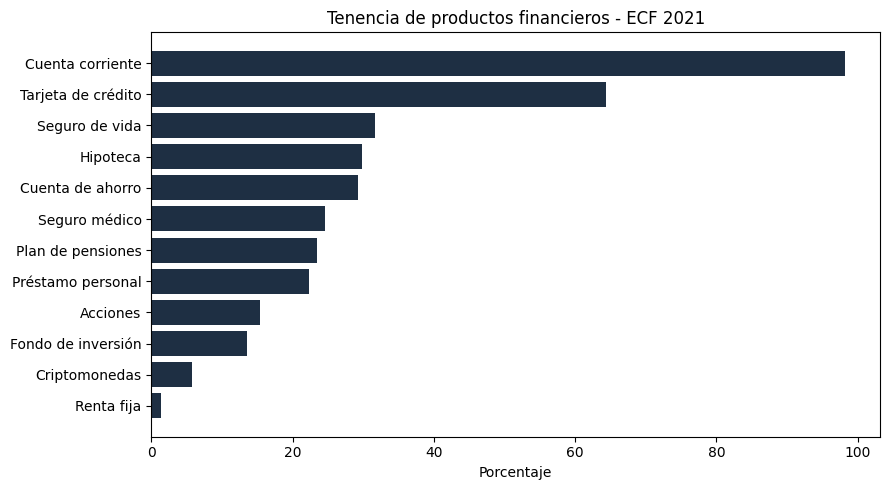

In [7]:
tenencia = tabla_porcentajes(eda_limpio, productos_tenencia)
display(tenencia)

grafico_barras(
    tenencia,
    titulo='Tenencia de productos financieros - ECF 2021',
    color='#1E2F43'  # azul oscuro corporativo
)


**Lectura de negocio:** los productos con mayor tenencia representan la base de relación bancaria. Los productos con menor penetración pueden ser oportunidades de crecimiento si se diseñan ofertas simples y bien segmentadas.

## 8. Adquisición reciente de productos financieros

Aquí se analiza qué productos financieros ha adquirido recientemente la población.

,variable,indicador,porcentaje
8,b0407,Tarjeta de crédito,17.314269
10,b0406,Préstamo personal,17.062393
0,b0408,Cuenta de ahorro,11.329988
6,b0409,Seguro de vida,10.775402
7,b0410,Seguro médico,10.199033
2,b0403,Fondo de inversión,8.173649
3,b0404,Acciones,7.496578
5,b0412,Criptomonedas,6.197703
9,b0401,Hipoteca,4.647476
1,b0402,Plan de pensiones,2.855595


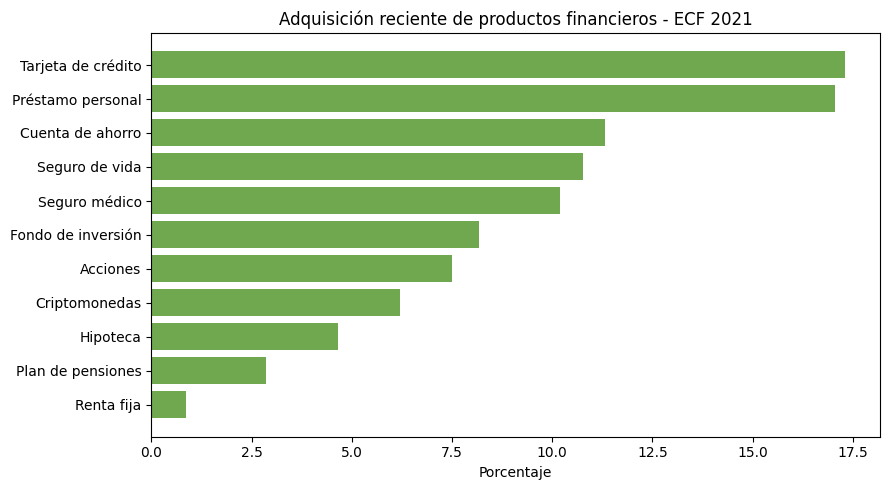

In [8]:
adquisicion = tabla_porcentajes(eda_limpio, productos_adquisicion)
display(adquisicion)

grafico_barras(
    adquisicion,
    titulo='Adquisición reciente de productos financieros - ECF 2021',
    color='#6FA84F'  # verde corporativo
)


**Lectura de negocio:** los productos con mayor adquisición reciente indican demanda activa. Estos productos pueden ser prioritarios para campañas comerciales o paquetes de venta cruzada.

## 9. Comparación entre tenencia y adquisición

Esta tabla ayuda a ver productos ya consolidados y productos con potencial de crecimiento.

In [9]:
comparativa = tenencia[['indicador', 'porcentaje']].rename(columns={'porcentaje': 'tenencia_%'}).merge(
    adquisicion[['indicador', 'porcentaje']].rename(columns={'porcentaje': 'adquisicion_%'}),
    on='indicador',
    how='outer'
)

comparativa['diferencia_tenencia_adquisicion'] = comparativa['tenencia_%'] - comparativa['adquisicion_%']

# Clasificación simple para interpretar oportunidades de negocio
umbral_tenencia = comparativa['tenencia_%'].median()
umbral_adquisicion = comparativa['adquisicion_%'].median()

def clasificar_oportunidad(row):
    if row['tenencia_%'] >= umbral_tenencia and row['adquisicion_%'] >= umbral_adquisicion:
        return 'Producto fuerte: mantener e impulsar venta cruzada'
    elif row['tenencia_%'] >= umbral_tenencia and row['adquisicion_%'] < umbral_adquisicion:
        return 'Producto maduro: fidelización y productos complementarios'
    elif row['tenencia_%'] < umbral_tenencia and row['adquisicion_%'] >= umbral_adquisicion:
        return 'Producto emergente: reforzar captación'
    else:
        return 'Baja adopción: simplificar oferta y mejorar comunicación'

comparativa['lectura_negocio'] = comparativa.apply(clasificar_oportunidad, axis=1)
comparativa = comparativa.sort_values('tenencia_%', ascending=False)

display(comparativa)


,indicador,tenencia_%,adquisicion_%,diferencia_tenencia_adquisicion,lectura_negocio
2,Cuenta corriente,98.257753,NaN,NaN,Baja adopción: simplificar oferta y mejorar co...
11,Tarjeta de crédito,64.313560,17.314269,46.999290,Producto fuerte: mantener e impulsar venta cru...
9,Seguro de vida,31.737585,10.775402,20.962183,Producto fuerte: mantener e impulsar venta cru...
5,Hipoteca,29.886082,4.647476,25.238605,Producto maduro: fidelización y productos comp...
3,Cuenta de ahorro,29.307342,11.329988,17.977354,Producto fuerte: mantener e impulsar venta cru...
10,Seguro médico,24.621934,10.199033,14.422901,Producto fuerte: mantener e impulsar venta cru...
6,Plan de pensiones,23.439671,2.855595,20.584076,Baja adopción: simplificar oferta y mejorar co...
7,Préstamo personal,22.296155,17.062393,5.233762,Producto emergente: reforzar captación
0,Acciones,15.346025,7.496578,7.849446,Baja adopción: simplificar oferta y mejorar co...
4,Fondo de inversión,13.606266,8.173649,5.432617,Producto emergente: reforzar captación


**Lectura de negocio:**

- Alta tenencia y alta adquisición: productos activos y relevantes.
- Alta tenencia y baja adquisición: productos maduros, útiles para fidelización o venta cruzada.
- Baja tenencia y cierta adquisición: productos con posible oportunidad de crecimiento.

## 10. Comportamiento financiero por edad

Se analizan productos clave por grupo de edad.

,grupo_edad,indicador,porcentaje
0,18-34,Hipoteca,11.445310
1,35-44,Hipoteca,47.741378
2,45-54,Hipoteca,49.004026
3,55-64,Hipoteca,28.312701
4,65-79,Hipoteca,14.432140
5,18-34,Préstamo personal,17.870984
6,35-44,Préstamo personal,30.364099
7,45-54,Préstamo personal,27.707382
8,55-64,Préstamo personal,23.550326
9,65-79,Préstamo personal,11.415259


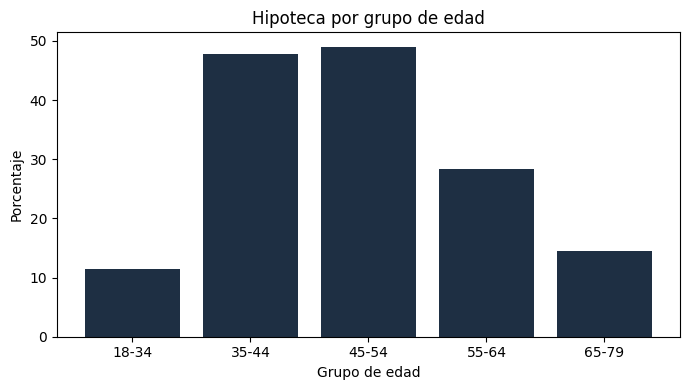

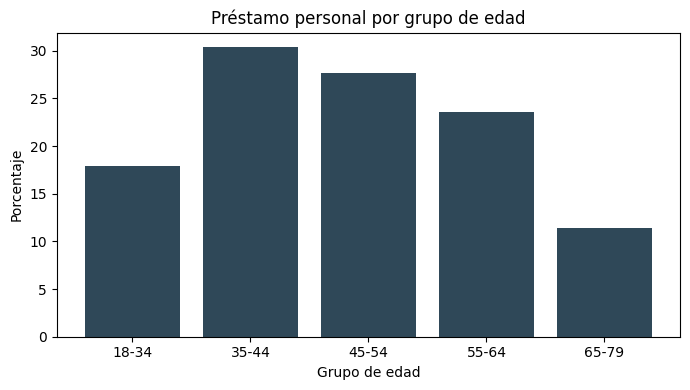

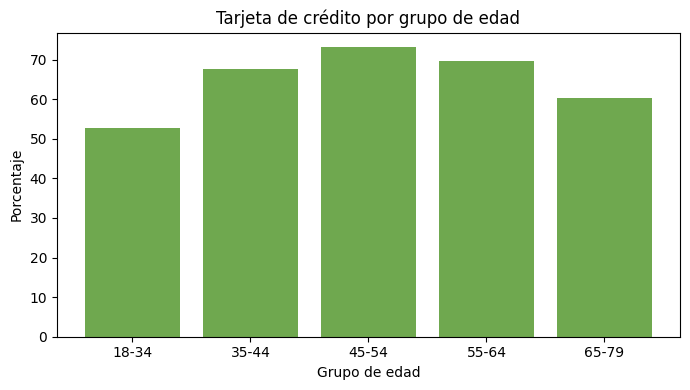

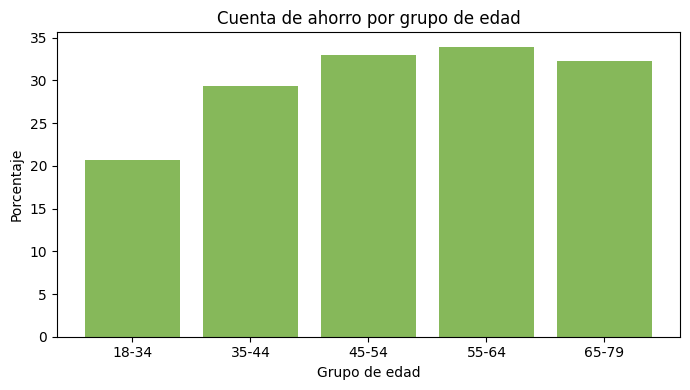

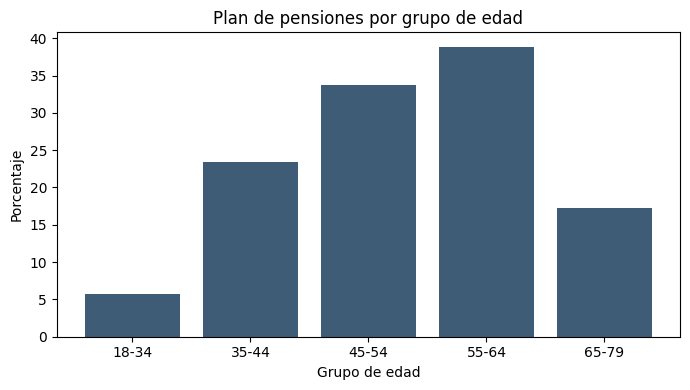

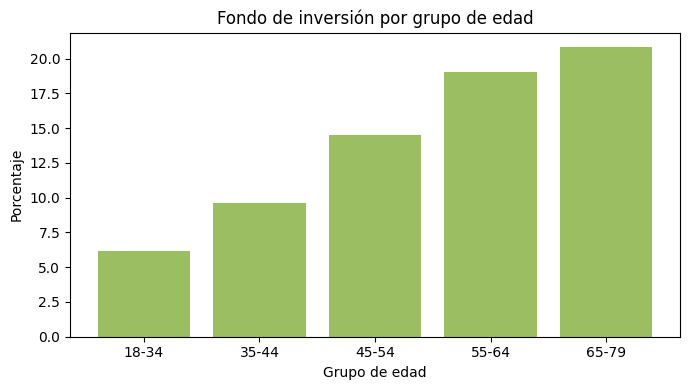

In [10]:
productos_clave = {
    'b0301': 'Hipoteca',
    'b0306': 'Préstamo personal',
    'b0307': 'Tarjeta de crédito',
    'b0308': 'Cuenta de ahorro',
    'b0302': 'Plan de pensiones',
    'b0303': 'Fondo de inversión'
}

edad_productos = tabla_por_grupo(eda_limpio, productos_clave, 'grupo_edad')
display(edad_productos.head(20))

for indicador in edad_productos['indicador'].dropna().unique():
    temp = edad_productos[edad_productos['indicador'] == indicador].dropna()
    
    color = {
        'Hipoteca': '#1E2F43',
        'Préstamo personal': '#2F4858',
        'Tarjeta de crédito': '#6FA84F',
        'Cuenta de ahorro': '#86B85A',
        'Plan de pensiones': '#3E5C76',
        'Fondo de inversión': '#9BBE63'
    }.get(indicador, '#1E2F43')
    
    plt.figure(figsize=(7, 4))
    plt.bar(temp['grupo_edad'].astype(str), temp['porcentaje'], color=color)
    plt.title(f'{indicador} por grupo de edad')
    plt.xlabel('Grupo de edad')
    plt.ylabel('Porcentaje')
    plt.tight_layout()
    plt.show()


**Lectura de negocio:** la edad permite detectar etapas vitales. Las hipotecas y préstamos suelen asociarse a edades adultas, mientras que ahorro e inversión pueden requerir propuestas diferentes según el momento vital.

## 11. Ahorro, crédito y presión económica

Estos indicadores ayudan a identificar necesidades de productos de ahorro, financiación responsable y salud financiera.

,variable,indicador,porcentaje
0,e1200,Ha ahorrado / comportamiento de ahorro,70.693274
3,j0100,Ha tenido necesidad de crédito,64.929485
2,j0110,Ha pedido dinero o crédito,37.856457
1,j0200,Gastos superiores a ingresos,25.432683


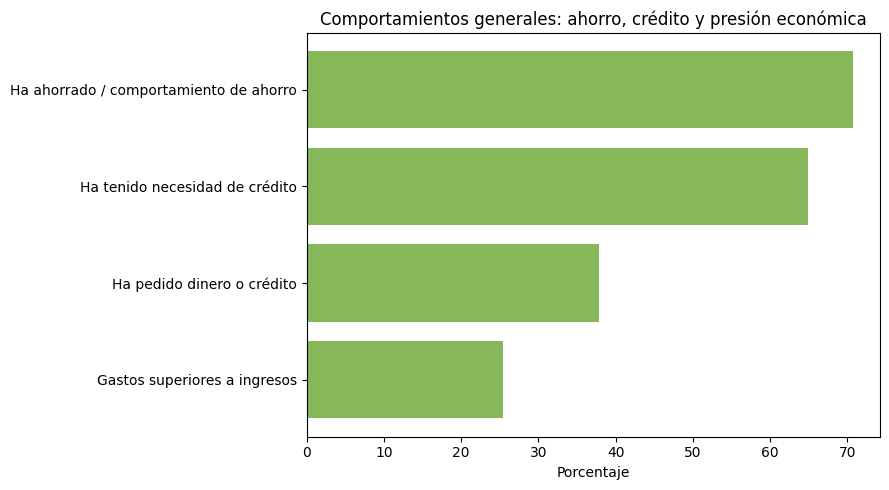

In [11]:
general = tabla_porcentajes(eda_limpio, comportamientos_generales)
display(general)

grafico_barras(
    general,
    titulo='Comportamientos generales: ahorro, crédito y presión económica',
    color='#86B85A'  # verde claro corporativo
)


## 12. Ahorro y presión económica por edad

,grupo_edad,indicador,porcentaje
0,18-34,Ha ahorrado / comportamiento de ahorro,75.222734
1,35-44,Ha ahorrado / comportamiento de ahorro,74.442381
2,45-54,Ha ahorrado / comportamiento de ahorro,69.442992
3,55-64,Ha ahorrado / comportamiento de ahorro,66.727616
4,65-79,Ha ahorrado / comportamiento de ahorro,65.377198
5,18-34,Gastos superiores a ingresos,23.713058
6,35-44,Gastos superiores a ingresos,26.171422
7,45-54,Gastos superiores a ingresos,28.544490
8,55-64,Gastos superiores a ingresos,26.993253
9,65-79,Gastos superiores a ingresos,21.818546


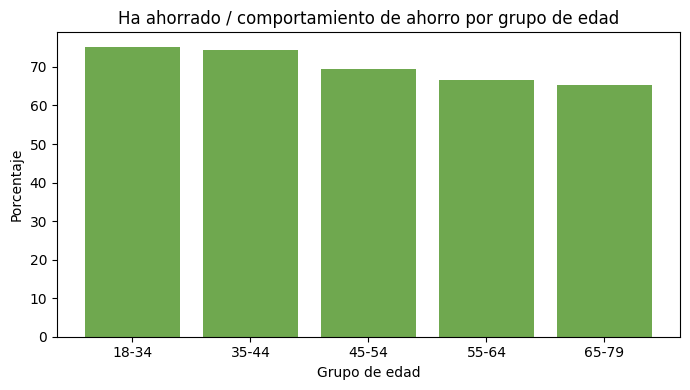

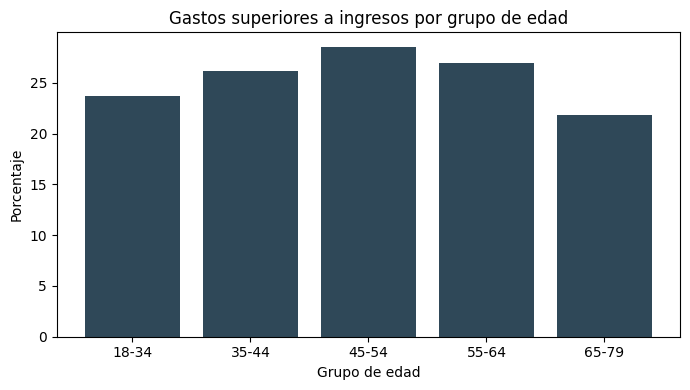

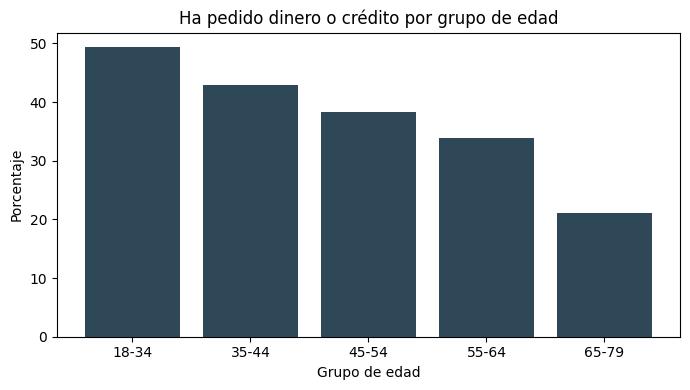

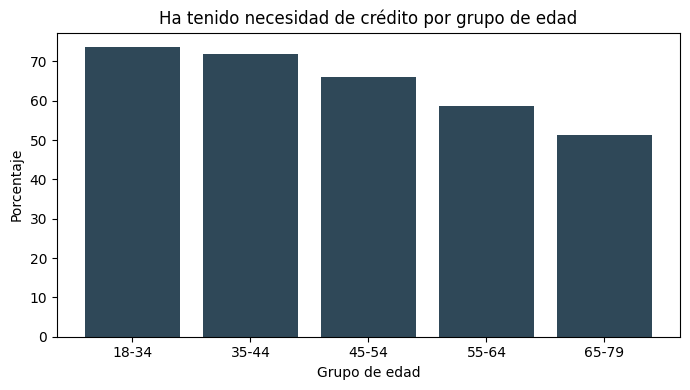

In [12]:
general_edad = tabla_por_grupo(eda_limpio, comportamientos_generales, 'grupo_edad')
display(general_edad)

for indicador in general_edad['indicador'].dropna().unique():
    temp = general_edad[general_edad['indicador'] == indicador].dropna()
    
    if 'Gastos' in indicador or 'crédito' in indicador.lower():
        color = '#2F4858'  # azul grisáceo para presión financiera/crédito
    else:
        color = '#6FA84F'  # verde corporativo para ahorro
    
    plt.figure(figsize=(7, 4))
    plt.bar(temp['grupo_edad'].astype(str), temp['porcentaje'], color=color)
    plt.title(f'{indicador} por grupo de edad')
    plt.xlabel('Grupo de edad')
    plt.ylabel('Porcentaje')
    plt.tight_layout()
    plt.show()


**Lectura de negocio:** si un grupo combina baja capacidad de ahorro y mayor presión económica, no conviene ofrecerle productos complejos o deuda agresiva. En esos casos tienen más sentido herramientas de control de gasto, microahorro y crédito responsable.

## 13. Validación estadística de diferencias entre grupos

Para responder a la recomendación de validar las diferencias encontradas, se aplica el **test Chi-cuadrado de independencia** sobre los microdatos.

Este test permite comprobar si la relación observada entre dos variables categóricas, por ejemplo grupo de edad y tenencia de hipoteca, puede considerarse estadísticamente significativa.

**Hipótesis del test:**

- H0: no existe relación estadísticamente significativa entre las variables.
- H1: sí existe relación estadísticamente significativa entre las variables.

Se toma como referencia un nivel de significación del 5%. Si el `p-value` es menor que 0,05, se considera que la diferencia entre grupos es estadísticamente significativa.


In [13]:
from scipy.stats import chi2_contingency

def test_chi_cuadrado_microdatos(df, variable_grupo, variable_respuesta, nombre_respuesta=None):
    """Aplica Chi-cuadrado entre una variable de grupo y una variable binaria 0/1."""
    nombre_respuesta = nombre_respuesta or variable_respuesta

    temp = df[[variable_grupo, variable_respuesta]].dropna().copy()
    temp = temp[temp[variable_respuesta].isin([0, 1])]

    tabla = pd.crosstab(temp[variable_grupo], temp[variable_respuesta])

    # El test necesita al menos dos filas y dos columnas
    if tabla.shape[0] < 2 or tabla.shape[1] < 2:
        print(f'No se puede aplicar el test para {nombre_respuesta}: tabla insuficiente.')
        return None

    chi2, p_value, dof, expected = chi2_contingency(tabla)

    resultado = {
        'variable_grupo': variable_grupo,
        'variable_respuesta': variable_respuesta,
        'indicador': nombre_respuesta,
        'chi2': chi2,
        'p_value': p_value,
        'grados_libertad': dof,
        'significativo_5%': 'Sí' if p_value < 0.05 else 'No'
    }

    print(f'Indicador: {nombre_respuesta}')
    print(f'Chi2: {chi2:.4f}')
    print(f'p-value: {p_value:.6f}')
    print('Conclusión:', 'Diferencia estadísticamente significativa' if p_value < 0.05 else 'No se observa diferencia estadísticamente significativa')
    display(tabla)

    return resultado


# Tests principales: diferencias por grupo de edad
tests_a_realizar = {
    'b0301': 'Tenencia de hipoteca',
    'b0306': 'Tenencia de préstamo personal',
    'b0307': 'Tenencia de tarjeta de crédito',
    'b0308': 'Tenencia de cuenta de ahorro',
    'b0302': 'Tenencia de plan de pensiones',
    'b0303': 'Tenencia de fondo de inversión',
    'e1200': 'Ha ahorrado / comportamiento de ahorro',
    'j0200': 'Gastos superiores a ingresos',
    'j0110': 'Ha pedido dinero o crédito',
    'j0100': 'Ha tenido necesidad de crédito'
}

resultados_tests = []

for variable, nombre in tests_a_realizar.items():
    if variable in eda_limpio.columns:
        res = test_chi_cuadrado_microdatos(eda_limpio, 'grupo_edad', variable, nombre)
        if res is not None:
            resultados_tests.append(res)
        print('-' * 80)

resultados_tests = pd.DataFrame(resultados_tests)
display(resultados_tests.sort_values('p_value'))


Indicador: Tenencia de hipoteca
Chi2: 996.2310
p-value: 0.000000
Conclusión: Diferencia estadísticamente significativa


b0301,0.0,1.0
grupo_edad,,
18-34,1647,210
35-44,737,712
45-54,900,883
55-64,1020,400
65-79,958,160


--------------------------------------------------------------------------------
Indicador: Tenencia de préstamo personal
Chi2: 158.6098
p-value: 0.000000
Conclusión: Diferencia estadísticamente significativa


b0306,0.0,1.0
grupo_edad,,
18-34,1450,288
35-44,1013,418
45-54,1282,471
55-64,1093,294
65-79,935,130


--------------------------------------------------------------------------------
Indicador: Tenencia de tarjeta de crédito
Chi2: 232.2955
p-value: 0.000000
Conclusión: Diferencia estadísticamente significativa


...

j0110,0.0,1.0
grupo_edad,,
18-34,949,927
35-44,807,663
45-54,1088,711
55-64,945,494
65-79,877,260


--------------------------------------------------------------------------------
Indicador: Ha tenido necesidad de crédito
Chi2: 222.3106
p-value: 0.000000
Conclusión: Diferencia estadísticamente significativa


j0100,0.0,1.0
grupo_edad,,
18-34,509,1346
35-44,459,1012
45-54,641,1159
55-64,629,807
65-79,580,553


--------------------------------------------------------------------------------


,variable_grupo,variable_respuesta,indicador,chi2,p_value,grados_libertad,significativo_5%
0,grupo_edad,b0301,Tenencia de hipoteca,996.230988,2.340942e-214,4,Sí
4,grupo_edad,b0302,Tenencia de plan de pensiones,638.377324,7.647708e-137,4,Sí
8,grupo_edad,j0110,Ha pedido dinero o crédito,244.021932,1.262567e-51,4,Sí
2,grupo_edad,b0307,Tenencia de tarjeta de crédito,232.295542,4.230562e-49,4,Sí
9,grupo_edad,j0100,Ha tenido necesidad de crédito,222.310614,5.966001e-47,4,Sí
5,grupo_edad,b0303,Tenencia de fondo de inversión,217.484997,6.517900e-46,4,Sí
1,grupo_edad,b0306,Tenencia de préstamo personal,158.609831,2.904390e-33,4,Sí
3,grupo_edad,b0308,Tenencia de cuenta de ahorro,74.456002,2.596966e-15,4,Sí
6,grupo_edad,e1200,Ha ahorrado / comportamiento de ahorro,56.426743,1.631812e-11,4,Sí
7,grupo_edad,j0200,Gastos superiores a ingresos,18.089903,1.185156e-03,4,Sí


### Lectura de los test estadísticos

Los resultados del test Chi-cuadrado permiten reforzar el análisis descriptivo. Si un indicador presenta un `p-value` inferior a 0,05, se puede afirmar que las diferencias observadas entre grupos de edad no parecen deberse únicamente al azar.

Esto permite justificar con mayor solidez conclusiones como que determinados productos financieros o comportamientos económicos varían según el perfil de edad de la población.

En términos de negocio, estos resultados apoyan la necesidad de segmentar la oferta bancaria según perfiles, especialmente en productos como hipotecas, préstamos, tarjetas, ahorro e inversión.


# Conclusiones finales: comportamiento financiero y oportunidades de negocio

El análisis de los microdatos de la ECF 2021 permite identificar patrones relevantes sobre el comportamiento financiero de la población española. Se observa qué productos financieros están más extendidos, cuáles se adquieren con mayor frecuencia y qué oportunidades puede aprovechar el banco para adaptar su estrategia comercial.

## 1. Productos financieros consolidados

Los productos con mayor presencia son la cuenta corriente, la tarjeta de crédito, el seguro de vida, la hipoteca y la cuenta de ahorro. La cuenta corriente aparece como el producto más extendido, por lo que funciona como producto base de relación bancaria.

**Interpretación de negocio:** estos productos ya forman parte del comportamiento financiero habitual de la población. Por tanto, no representan tanto una oportunidad de captación nueva, sino una base para fidelización y venta cruzada.

**Recomendación:** utilizar los productos básicos como entrada para ofrecer paquetes personalizados:

- Cuenta + tarjeta + ahorro automático.
- Cuenta nómina + seguro + financiación.
- Cuenta digital + alertas de gasto + objetivos de ahorro.

## 2. Productos con mayor adquisición reciente

La adquisición reciente se concentra principalmente en tarjeta de crédito, préstamo personal, cuenta de ahorro, seguros y fondos de inversión. Esto indica que existe una demanda activa en productos relacionados con financiación, ahorro y protección.

**Interpretación de negocio:** estos productos deberían ser prioritarios para campañas comerciales, ya que muestran movimiento real de contratación.

**Recomendación:** reforzar la oferta de estos productos mediante:

- Procesos de contratación más simples.
- Campañas segmentadas por perfil de cliente.
- Productos complementarios asociados.
- Mejora de la experiencia digital.
- Simuladores y asesoramiento claro.

## 3. Financiación: hipotecas, préstamos y crédito

Las hipotecas tienen una mayor presencia en edades adultas, especialmente en los grupos de 35 a 54 años. Los préstamos personales y la necesidad de crédito también muestran diferencias claras por edad.

**Interpretación de negocio:** la financiación debe adaptarse al momento vital del cliente. No todos los grupos necesitan el mismo tipo de crédito ni tienen la misma capacidad de pago.

**Recomendación:** crear ofertas diferenciadas:

- Hipoteca + seguro de hogar + seguro de vida.
- Préstamo personal con análisis de capacidad de pago.
- Financiación responsable con cuotas claras.
- Campañas específicas para adultos con mayor estabilidad económica.

## 4. Ahorro e inversión

El 70,69% de la población muestra comportamiento de ahorro, pero la tenencia de productos de inversión como fondos, acciones, planes de pensiones o renta fija es menor. Esto indica que muchas personas ahorran, pero no necesariamente usan productos financieros más planificados.

**Interpretación de negocio:** existe una oportunidad para convertir el ahorro básico en ahorro estructurado o inversión sencilla.

**Recomendación:** impulsar productos como:

- Ahorro automático mensual.
- Cuentas remuneradas.
- Objetivos de ahorro desde la app.
- Fondos de bajo riesgo.
- Planes de ahorro conservadores.
- Educación financiera vinculada al producto.

## 5. Productos con baja adquisición pero potencial

Productos como fondos de inversión, planes de pensiones, renta fija o criptomonedas tienen menor presencia o adquisición. Esto puede estar relacionado con desconocimiento, percepción de riesgo o complejidad.

**Interpretación de negocio:** no deben descartarse, pero necesitan una estrategia más educativa y simplificada.

**Recomendación:** para aumentar su adopción, el banco debería:

- Usar lenguaje sencillo.
- Evitar tecnicismos.
- Ofrecer importes iniciales bajos.
- Crear simuladores de rentabilidad y riesgo.
- Acompañar la contratación con asesoramiento.
- Explicar beneficios con ejemplos prácticos.

## 6. Diferencias por perfil de cliente

El análisis por edad y los test Chi-cuadrado muestran que existen diferencias estadísticamente significativas entre grupos. Esto confirma que el comportamiento financiero no es homogéneo.

**Interpretación de negocio:** la estrategia bancaria no debería ser igual para todos los clientes. La segmentación es necesaria para ofrecer productos adecuados a cada perfil.

**Recomendación por segmento:**

- Jóvenes: cuenta digital, tarjeta, ahorro automático, educación financiera y productos simples.
- Adultos: hipoteca, préstamo personal, seguros, cuenta nómina y planificación familiar.
- Rentas altas: fondos de inversión, planes de pensiones y asesoramiento patrimonial.
- Rentas bajas o perfiles vulnerables: control de gastos, microahorro, alertas y crédito responsable.
- Personas mayores: ahorro seguro, pensiones, productos conservadores y atención personalizada.

## 7. Conclusión general

Sí es recomendable ajustar la estrategia de negocio del banco. El análisis muestra que la población utiliza y adquiere productos financieros de forma diferente según su perfil, especialmente por edad.

La estrategia debería centrarse en tres líneas principales:

1. Reforzar los productos con alta adquisición, como tarjetas, préstamos, cuentas de ahorro y seguros.
2. Impulsar productos con menor adopción pero potencial, como fondos de inversión, planes de pensiones y ahorro planificado.
3. Segmentar las ofertas según el perfil del cliente, evitando una estrategia única para toda la población.

En conclusión, no se trata de cambiar completamente la estrategia bancaria, sino de adaptarla al comportamiento financiero real observado en los microdatos. El banco debería combinar productos básicos, financiación responsable, ahorro estructurado y educación financiera para maximizar las oportunidades de mercado.